In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [3]:
benchmark_file = "benchmark_results_with_control.json"
with open(benchmark_file, "r") as f:
    data = json.load(f)
correct_answers = np.array([item["target"] for item in data])
base_answers = np.array([item["base_extracted"] for item in data])
lora_answers = np.array([item["lora_extracted"] for item in data])
control_answers = np.array([item["control_extracted"] for item in data])
base_correct = np.array([item["base_correct"] for item in data])
lora_correct = np.array([item["lora_correct"] for item in data])
control_correct = np.array([item["control_correct"] for item in data])
base_differences = np.abs(correct_answers - base_answers)
lora_differences = np.abs(correct_answers - lora_answers)
control_differences = np.abs(correct_answers - control_answers)
base_accuracy = np.mean(base_correct)
lora_accuracy = np.mean(lora_correct)
control_accuracy = np.mean(control_correct)
base_diff_mean = np.mean(base_differences)
lora_diff_mean = np.mean(lora_differences)
control_diff_mean = np.mean(control_differences)
print(f"Base Model Accuracy: {base_accuracy:.2%}")
print(f"LoRA Model Accuracy: {lora_accuracy:.2%}")
print(f"Control Model Accuracy: {control_accuracy:.2%}")
print(f"Base Model Average Difference: {base_diff_mean:.4f}")
print(f"LoRA Model Average Difference: {lora_diff_mean:.4f}")
print(f"Control Model Average Difference: {control_diff_mean:.4f}")

Base Model Accuracy: 77.70%
LoRA Model Accuracy: 78.00%
Control Model Accuracy: 80.40%
Base Model Average Difference: 514.3730
LoRA Model Average Difference: 275.0170
Control Model Average Difference: 175.3110


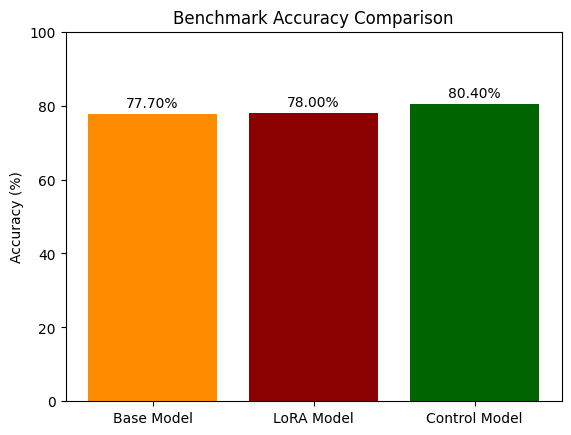

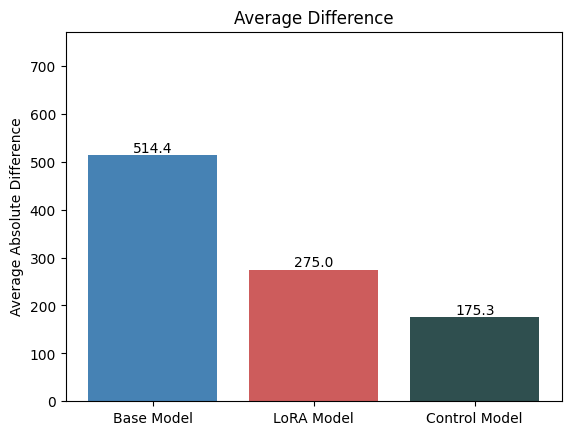

In [5]:
plt.bar(["Base Model", "LoRA Model", "Control Model"], [base_accuracy * 100, lora_accuracy * 100, control_accuracy * 100], color=["darkorange", "darkred", "darkgreen"])
plt.text(0, base_accuracy * 100 + 1, f"{base_accuracy:.2%}", ha="center", va="bottom", color="black")
plt.text(1, lora_accuracy * 100 + 1, f"{lora_accuracy:.2%}", ha="center", va="bottom", color="black")
plt.text(2, control_accuracy * 100 + 1, f"{control_accuracy:.2%}", ha="center", va="bottom", color="black")
plt.ylabel("Accuracy (%)")
plt.title("Benchmark Accuracy Comparison")
plt.ylim(0, 100)
plt.show()

plt.bar(["Base Model", "LoRA Model", "Control Model"], [base_diff_mean, lora_diff_mean, control_diff_mean], color=["steelblue", "indianred", "darkslategray"])
plt.text(0, base_diff_mean + 0.01, f"{base_diff_mean:.1f}", ha="center", va="bottom", color="black")
plt.text(1, lora_diff_mean + 0.01, f"{lora_diff_mean:.1f}", ha="center", va="bottom", color="black")
plt.text(2, control_diff_mean + 0.01, f"{control_diff_mean:.1f}", ha="center", va="bottom", color="black")
plt.ylabel("Average Absolute Difference")
plt.ylim(0, max(base_diff_mean, lora_diff_mean, control_diff_mean) * 1.5)
plt.title("Average Difference")
plt.show()

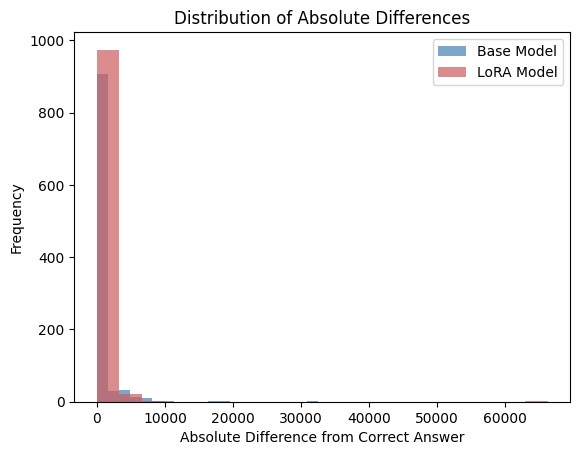

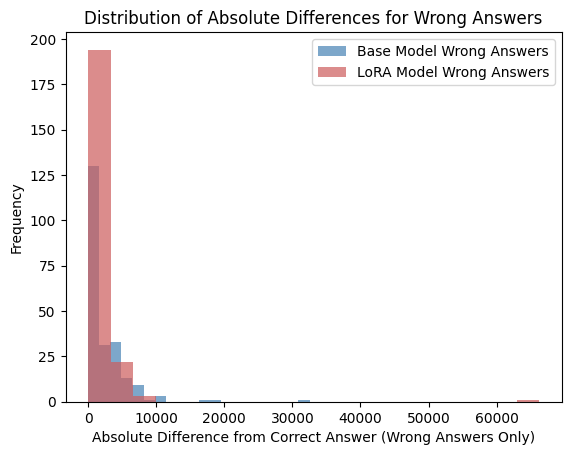

In [5]:
# its weird how the difference is so drastically different, 1175 for the base model is absurdly high compared to the 90 from the lora considering there was absolutely no finetuning for math problems or anything that should improve reasoning capacity.
# we should see the distribution difference in these differences, maybe the base model has a few outliers that are skewing the average, while the lora model is more consistent. we can plot histograms of the differences to see this.

plt.hist(base_differences, bins=20, alpha=0.7, label="Base Model", color="steelblue")
plt.hist(lora_differences, bins=20, alpha=0.7, label="LoRA Model", color="indianred")
plt.xlabel("Absolute Difference from Correct Answer")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Differences")
plt.legend()
plt.show()

# now the same thing but including only wrong answers, to see if the lora model is making smaller mistakes when it does get it wrong, compared to the base model which might be making huge mistakes when it gets it wrong. this could explain the large difference in average differences.
base_wrong_differences = base_differences[~base_correct]
lora_wrong_differences = lora_differences[~lora_correct]
plt.hist(base_wrong_differences, bins=20, alpha=0.7, label="Base Model Wrong Answers", color="steelblue")
plt.hist(lora_wrong_differences, bins=20, alpha=0.7, label="LoRA Model Wrong Answers", color="indianred")
plt.xlabel("Absolute Difference from Correct Answer (Wrong Answers Only)")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Differences for Wrong Answers")
plt.legend()
plt.show()

In [6]:
perc_num = 99.5
print(f"Base Model {perc_num}th Percentile: {np.percentile(base_differences, perc_num)}")
print(f"LoRA Model {perc_num}th Percentile: {np.percentile(lora_differences, perc_num)}")
print(f"Control Model {perc_num}th Percentile: {np.percentile(control_differences, perc_num)}")

Base Model 99.5th Percentile: 9768.75
LoRA Model 99.5th Percentile: 6300.5
Control Model 99.5th Percentile: 6401.699999999999


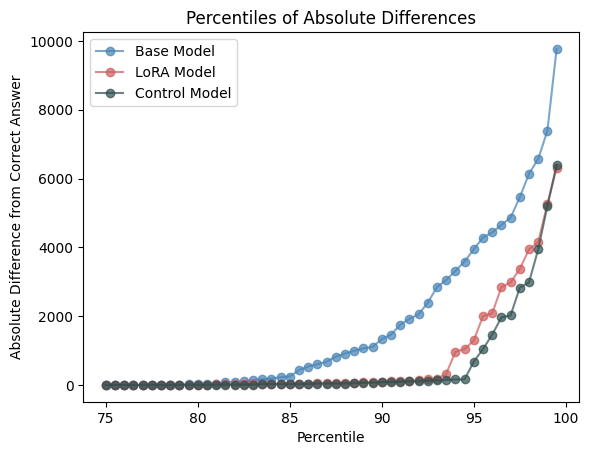

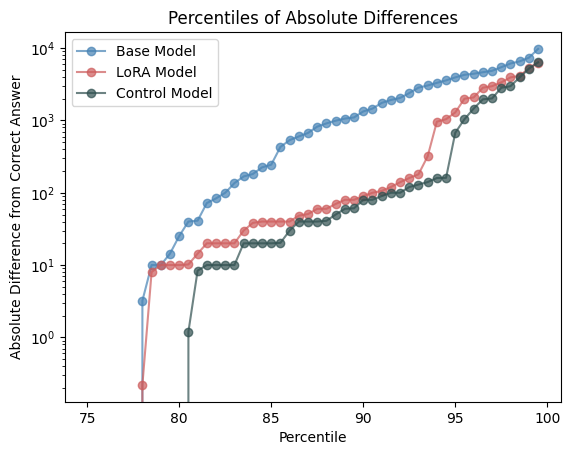

In [7]:
# now compare each 10th percentile of the differences to see how they compare between the two models.

percentiles = np.arange(75, 100, 0.5)
base_percentiles = np.percentile(base_differences, percentiles)
lora_percentiles = np.percentile(lora_differences, percentiles)
control_percentiles = np.percentile(control_differences, percentiles)
plt.plot(percentiles, base_percentiles, marker="o", label="Base Model", color="steelblue", alpha=0.7)
plt.plot(percentiles, lora_percentiles, marker="o", label="LoRA Model", color="indianred", alpha=0.7)
plt.plot(percentiles, control_percentiles, marker="o", label="Control Model", color="darkslategray", alpha=0.7)
plt.xlabel("Percentile")
plt.ylabel("Absolute Difference from Correct Answer")
plt.title("Percentiles of Absolute Differences")
plt.legend()
plt.show()

plt.plot(percentiles, base_percentiles, marker="o", label="Base Model", color="steelblue", alpha=0.7)
plt.plot(percentiles, lora_percentiles, marker="o", label="LoRA Model", color="indianred", alpha=0.7)
plt.plot(percentiles, control_percentiles, marker="o", label="Control Model", color="darkslategray", alpha=0.7)
plt.xlabel("Percentile")
plt.ylabel("Absolute Difference from Correct Answer")
plt.yscale("log")
plt.title("Percentiles of Absolute Differences")
plt.legend()
plt.show()


Base Model Average Difference (Shaved): 181.5389
LoRA Model Average Difference (Shaved): 25.2874
Control Model Average Difference (Shaved): 10.1074


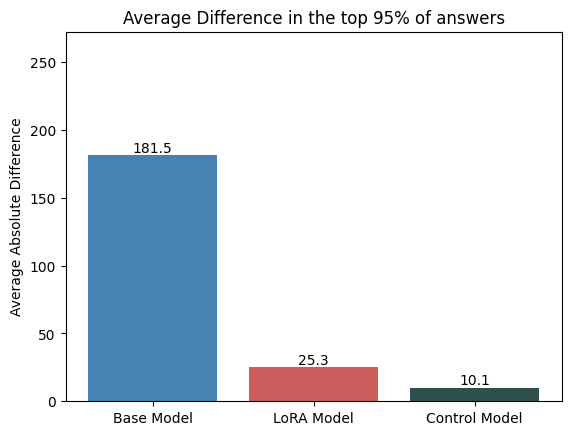

In [10]:
# shave off the top 5% worst differences to see how the average looks without the extreme outliers, which might be skewing the average for the base model.
shave_percentile = 95
base_diff_mean_shaved = np.mean(base_differences[base_differences <= np.percentile(base_differences, shave_percentile)])
lora_diff_mean_shaved = np.mean(lora_differences[lora_differences <= np.percentile(lora_differences, shave_percentile)])
control_diff_mean_shaved = np.mean(control_differences[control_differences <= np.percentile(control_differences, shave_percentile)])
print(f"Base Model Average Difference (Shaved): {base_diff_mean_shaved:.4f}")
print(f"LoRA Model Average Difference (Shaved): {lora_diff_mean_shaved:.4f}")
print(f"Control Model Average Difference (Shaved): {control_diff_mean_shaved:.4f}")

plt.bar(["Base Model", "LoRA Model", "Control Model"], [base_diff_mean_shaved, lora_diff_mean_shaved, control_diff_mean_shaved], color=["steelblue", "indianred", "darkslategray"])
plt.text(0, base_diff_mean_shaved + 0.01, f"{base_diff_mean_shaved:.1f}", ha="center", va="bottom", color="black")
plt.text(1, lora_diff_mean_shaved + 0.01, f"{lora_diff_mean_shaved:.1f}", ha="center", va="bottom", color="black")
plt.text(2, control_diff_mean_shaved + 0.01, f"{control_diff_mean_shaved:.1f}", ha="center", va="bottom", color="black")
plt.ylabel("Average Absolute Difference")
plt.ylim(0, max(base_diff_mean_shaved, lora_diff_mean_shaved, control_diff_mean_shaved) * 1.5)
plt.title("Average Difference in the top 95% of answers")
plt.show()

Base Model Average Percentage Error (Non-Zero Correct Answers): 0.16
LoRA Model Average Percentage Error (Non-Zero Correct Answers): 0.15
Control Model Average Percentage Error (Non-Zero Correct Answers): 0.059


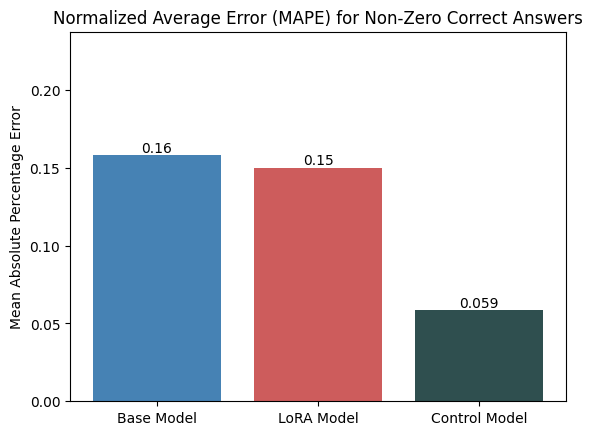

In [12]:
non_zero_correct_answers = correct_answers[correct_answers != 0]
non_zero_base_answers = base_answers[correct_answers != 0]
non_zero_lora_answers = lora_answers[correct_answers != 0]
non_zero_control_answers = control_answers[correct_answers != 0]

base_non_zero_differences = np.abs(non_zero_correct_answers - non_zero_base_answers)
lora_non_zero_differences = np.abs(non_zero_correct_answers - non_zero_lora_answers)
control_non_zero_differences = np.abs(non_zero_correct_answers - non_zero_control_answers)

base_non_zero_normalized_diff = base_non_zero_differences / np.abs(non_zero_correct_answers)
lora_non_zero_normalized_diff = lora_non_zero_differences / np.abs(non_zero_correct_answers)
control_non_zero_normalized_diff = control_non_zero_differences / np.abs(non_zero_correct_answers)

base_non_zero_mape = np.mean(base_non_zero_normalized_diff)
lora_non_zero_mape = np.mean(lora_non_zero_normalized_diff)
control_non_zero_mape = np.mean(control_non_zero_normalized_diff)

print(f"Base Model Average Percentage Error (Non-Zero Correct Answers): {base_non_zero_mape:.2}")
print(f"LoRA Model Average Percentage Error (Non-Zero Correct Answers): {lora_non_zero_mape:.2}")
print(f"Control Model Average Percentage Error (Non-Zero Correct Answers): {control_non_zero_mape:.2}")

plt.bar(["Base Model", "LoRA Model", "Control Model"], [base_non_zero_mape, lora_non_zero_mape, control_non_zero_mape], color=["steelblue", "indianred", "darkslategray"])
plt.text(0, base_non_zero_mape, f"{base_non_zero_mape:.2}", ha="center", va="bottom", color="black")
plt.text(1, lora_non_zero_mape, f"{lora_non_zero_mape:.2}", ha="center", va="bottom", color="black")
plt.text(2, control_non_zero_mape, f"{control_non_zero_mape:.2}", ha="center", va="bottom", color="black")
plt.ylabel("Mean Absolute Percentage Error")
plt.title("Normalized Average Error (MAPE) for Non-Zero Correct Answers")
plt.ylim(0, max(base_non_zero_mape, lora_non_zero_mape, control_non_zero_mape) * 1.5) 
plt.show()

Base Model Average Percentage Error (Shaved): 8.08%
LoRA Model Average Percentage Error (Shaved): 3.96%
Control Model Average Percentage Error (Shaved): 1.11%


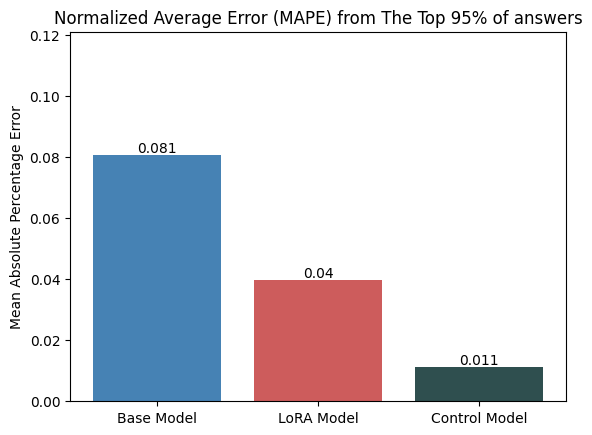

In [13]:
# shave off top 5% from the MAPE graph

shave_percentile = 95
base_non_zero_mape_shaved = np.mean(base_non_zero_normalized_diff[base_non_zero_normalized_diff <= np.percentile(base_non_zero_normalized_diff, shave_percentile)])
lora_non_zero_mape_shaved = np.mean(lora_non_zero_normalized_diff[lora_non_zero_normalized_diff <= np.percentile(lora_non_zero_normalized_diff, shave_percentile)])
control_non_zero_mape_shaved = np.mean(control_non_zero_normalized_diff[control_non_zero_normalized_diff <= np.percentile(control_non_zero_normalized_diff, shave_percentile)])
print(f"Base Model Average Percentage Error (Shaved): {base_non_zero_mape_shaved:.2%}")
print(f"LoRA Model Average Percentage Error (Shaved): {lora_non_zero_mape_shaved:.2%}")
print(f"Control Model Average Percentage Error (Shaved): {control_non_zero_mape_shaved:.2%}")

plt.bar(["Base Model", "LoRA Model", "Control Model"], [base_non_zero_mape_shaved, lora_non_zero_mape_shaved, control_non_zero_mape_shaved], color=["steelblue", "indianred", "darkslategray"])
plt.text(0, base_non_zero_mape_shaved, f"{base_non_zero_mape_shaved:.2}", ha="center", va="bottom", color="black")
plt.text(1, lora_non_zero_mape_shaved, f"{lora_non_zero_mape_shaved:.2}", ha="center", va="bottom", color="black")
plt.text(2, control_non_zero_mape_shaved, f"{control_non_zero_mape_shaved:.2}", ha="center", va="bottom", color="black")
plt.ylabel("Mean Absolute Percentage Error")
plt.title("Normalized Average Error (MAPE) from The Top 95% of answers")
plt.ylim(0, max(base_non_zero_mape_shaved, lora_non_zero_mape_shaved, control_non_zero_mape_shaved) * 1.5) 
plt.show()

Base 95.0 : 0.98 | LoRA 95.0 : 0.89 | Control 95.0 : 0.71


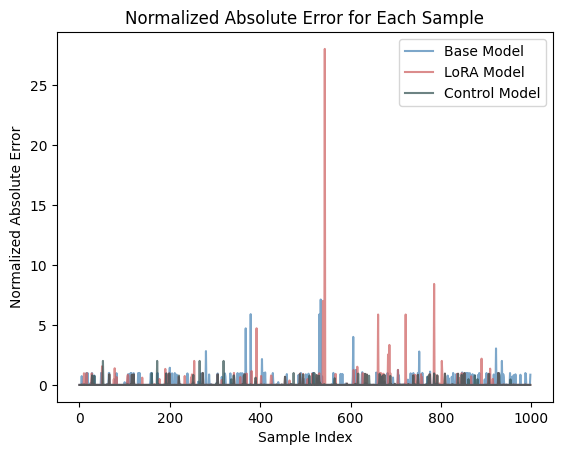

In [15]:
perc_2 = 95.0
print(f"Base {perc_2} : {np.percentile(base_non_zero_normalized_diff, perc_2):.2f} | LoRA {perc_2} : {np.percentile(lora_non_zero_normalized_diff, perc_2):.2f} | Control {perc_2} : {np.percentile(control_non_zero_normalized_diff, perc_2):.2f}")


plt.plot(base_non_zero_normalized_diff, label="Base Model", color="steelblue", alpha=0.7)
plt.plot(lora_non_zero_normalized_diff, label="LoRA Model", color="indianred", alpha=0.7)
plt.plot(control_non_zero_normalized_diff, label="Control Model", color="darkslategray", alpha=0.7)
plt.xlabel("Sample Index")
plt.ylabel("Normalized Absolute Error")
plt.title("Normalized Absolute Error for Each Sample")
plt.legend()
plt.show()

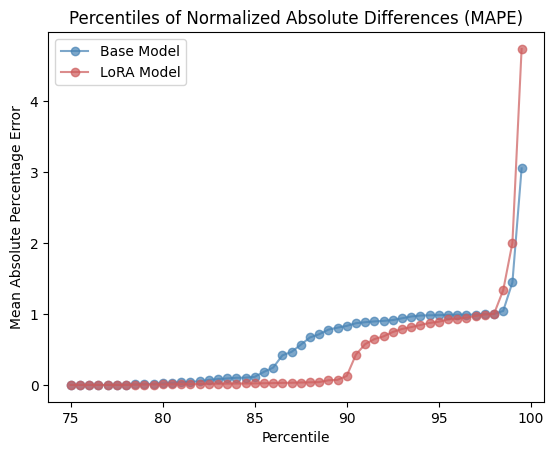

In [54]:
# now compare each 10th percentile of the differences to see how they compare between the two models.

percentiles = np.arange(75, 100, 0.5)
base_mape_percentiles = np.percentile(base_non_zero_normalized_diff, percentiles)
lora_mape_percentiles = np.percentile(lora_non_zero_normalized_diff, percentiles)
plt.plot(percentiles, base_mape_percentiles, marker="o", label="Base Model", color="steelblue", alpha=0.7)
plt.plot(percentiles, lora_mape_percentiles, marker="o", label="LoRA Model", color="indianred", alpha=0.7)
plt.xlabel("Percentile")
plt.ylabel("Mean Absolute Percentage Error")
plt.title("Percentiles of Normalized Absolute Differences (MAPE)")
plt.legend()
plt.show()